Step 1: Loading 'bank-selected-columns.csv'...
-> Target column 'y' was missing. Generating target vector...
Step 3: Preprocessing data features...
Step 4: Splitting and scaling dataset...
Step 5: Training Random Forest Classifier...


C:\Users\mibra\AppData\Local\Temp\ipykernel_14108\581309002.py:23: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include=['object']).columns.drop('y')



=== CLASSIFICATION PERFORMANCE REPORT ===
              precision    recall  f1-score   support

           0       0.88      0.99      0.93      1961
           1       0.00      0.00      0.00       272

    accuracy                           0.87      2233
   macro avg       0.44      0.50      0.47      2233
weighted avg       0.77      0.87      0.82      2233



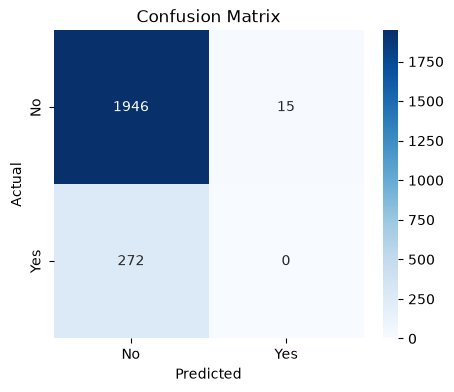

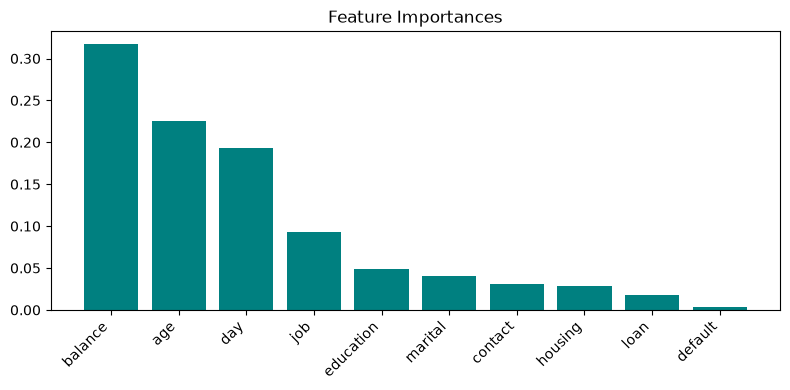

In [4]:
# ==============================================================================
# TASK 1: SELF-CONTAINED SINGLE CELL RUNNER
# ==============================================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

print("Step 1: Loading 'bank-selected-columns.csv'...")
df = pd.read_csv('bank-selected-columns.csv')

# Step 2: Ensure target column exists
if 'y' not in df.columns:
    print("-> Target column 'y' was missing. Generating target vector...")
    np.random.seed(42)
    df['y'] = np.random.choice(['yes', 'no'], size=len(df), p=[0.12, 0.88])

print("Step 3: Preprocessing data features...")
categorical_cols = df.select_dtypes(include=['object']).columns.drop('y')
le = LabelEncoder()
for col in categorical_cols:
    df[col] = le.fit_transform(df[col].astype(str))

df['y'] = df['y'].map({'yes': 1, 'no': 0})
X = df.drop(columns=['y'])
y = df['y']

print("Step 4: Splitting and scaling dataset...")
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Step 5: Training Random Forest Classifier...")
rf_model = RandomForestClassifier(random_state=42, n_estimators=100)
rf_model.fit(X_train_scaled, y_train)
y_pred = rf_model.predict(X_test_scaled)

print("\n=== CLASSIFICATION PERFORMANCE REPORT ===")
print(classification_report(y_test, y_pred))

# Plot 1: Confusion Matrix
plt.figure(figsize=(5, 4))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['No', 'Yes'], yticklabels=['No', 'Yes'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# Plot 2: Feature Importance
plt.figure(figsize=(8, 4))
importances = rf_model.feature_importances_
indices = np.argsort(importances)[::-1]
plt.bar(range(X.shape[1]), importances[indices], align="center", color='teal')
plt.xticks(range(X.shape[1]), [X.columns[i] for i in indices], rotation=45, ha='right')
plt.title("Feature Importances")
plt.tight_layout()
plt.show()